<h1> Preparação e Modelagem de Dados </h1>
Objetivo: Preparar as bases para criação da ABT incluindo criação de features, possíveis tratamentos de valores nulos entre outros</br>
Entrada: base de interações e clientes tratadas </br>
Saída: ABT pronta para rodar o modelo, modelo salvo para inferências. </br>

<h3> Importação de pacotes e bibliotecas </h3>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import joblib
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.model_selection import StratifiedKFold, cross_val_score,RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


<h3> Definição de Métodos e Funções </h3>

In [3]:
def criar_features_interacoes_30d(
    clientes,
    interacoes
):
    """
    Cria features de interações dos últimos 30 dias,
    considerando a data_referencia individual de cada cliente.
    """

    clientes = clientes.copy()
    interacoes = interacoes.copy()

    clientes["data_referencia"] = pd.to_datetime(
        clientes["data_referencia"]
    )

    interacoes["data_interacao"] = pd.to_datetime(
        interacoes["data_interacao"]
    )

    # ============================================================
    # ASSOCIAR DATA DE REFERÊNCIA
    # ============================================================

    interacoes = interacoes.merge(
        clientes[
            [
                "id_cliente",
                "data_referencia"
            ]
        ],
        on="id_cliente",
        how="inner"
    )

    # ============================================================
    # ÚLTIMOS 30 DIAS
    # ============================================================

    interacoes_30d = interacoes[
        (
            interacoes["data_interacao"]
            <= interacoes["data_referencia"]
        )
        &
        (
            interacoes["data_interacao"]
            >=
            interacoes["data_referencia"]
            - pd.Timedelta(days=30)
        )
    ].copy()

    # ============================================================
    # FEATURES BÁSICAS
    # ============================================================

    features = (
        interacoes_30d
        .groupby("id_cliente")
        .agg(
            qtd_interacoes_ult_30d=(
                "id_interacao",
                "count"
            ),

            data_ultima_interacao=(
                "data_interacao",
                "max"
            ),

            qtd_canais_distintos_ult_30d=(
                "canal",
                "nunique"
            )
        )
        .reset_index()
    )

    # ============================================================
    # INTERAÇÕES ATIVAS
    # ============================================================

    ativas = (
        interacoes_30d[
            interacoes_30d["direcao"] == "ativa"
        ]
        .groupby("id_cliente")
        .size()
        .rename(
            "qtd_interacoes_ativas_ult_30d"
        )
    )

    features = features.merge(
        ativas,
        on="id_cliente",
        how="left"
    )

    # ============================================================
    # INTERAÇÕES RECEPTIVAS
    # ============================================================

    receptivas = (
        interacoes_30d[
            interacoes_30d["direcao"] == "receptiva"
        ]
        .groupby("id_cliente")
        .size()
        .rename(
            "qtd_interacoes_receptivas_ult_30d"
        )
    )

    features = features.merge(
        receptivas,
        on="id_cliente",
        how="left"
    )

    # ============================================================
    # PROMESSAS REGISTRADAS
    # ============================================================

    promessas = (
        interacoes_30d[
            interacoes_30d["resultado"]
            == "promessa_registrada"
        ]
        .groupby("id_cliente")
        .size()
        .rename(
            "qtd_promessas_pagamento_ult_30d"
        )
    )

    features = features.merge(
        promessas,
        on="id_cliente",
        how="left"
    )

    # ============================================================
    # CLIENTES SEM INTERAÇÕES
    # ============================================================

    features[
        "qtd_interacoes_ativas_ult_30d"
    ] = features[
        "qtd_interacoes_ativas_ult_30d"
    ].fillna(0)

    features[
        "qtd_interacoes_receptivas_ult_30d"
    ] = features[
        "qtd_interacoes_receptivas_ult_30d"
    ].fillna(0)

    features[
        "qtd_promessas_pagamento_ult_30d"
    ] = features[
        "qtd_promessas_pagamento_ult_30d"
    ].fillna(0)

    # ============================================================
    # TEVE PROMESSA
    # ============================================================

    features[
        "teve_promessa_pagamento_ult_30d"
    ] = (
        features[
            "qtd_promessas_pagamento_ult_30d"
        ] > 0
    ).astype(int)

    # ============================================================
    # DATA DE REFERÊNCIA
    # ============================================================

    features = features.merge(
        clientes[
            [
                "id_cliente",
                "data_referencia"
            ]
        ],
        on="id_cliente",
        how="left"
    )

    # ============================================================
    # DIAS DESDE ÚLTIMA INTERAÇÃO
    # ============================================================

    features[
        "dias_desde_ultima_interacao"
    ] = (
        features["data_referencia"]
        - features["data_ultima_interacao"]
    ).dt.days

    # ============================================================
    # INCORPORAR CLIENTES SEM INTERAÇÃO
    # ============================================================

    clientes_features_target = clientes.merge(
        features[
            [
                "id_cliente",
                "qtd_interacoes_ult_30d",
                "dias_desde_ultima_interacao",
                "qtd_interacoes_ativas_ult_30d",
                "qtd_interacoes_receptivas_ult_30d",
                "qtd_canais_distintos_ult_30d",
                "teve_promessa_pagamento_ult_30d",
                "qtd_promessas_pagamento_ult_30d"
            ]
        ],
        on="id_cliente",
        how="left"
    )

    # ============================================================
    # CLIENTES SEM INTERAÇÃO NOS ÚLTIMOS 30 DIAS
    # ============================================================

    colunas_zero = [
        "qtd_interacoes_ult_30d",
        "qtd_interacoes_ativas_ult_30d",
        "qtd_interacoes_receptivas_ult_30d",
        "qtd_canais_distintos_ult_30d",
        "teve_promessa_pagamento_ult_30d",
        "qtd_promessas_pagamento_ult_30d"
    ]

    clientes_features_target[
        colunas_zero
    ] = clientes_features_target[
        colunas_zero
    ].fillna(0)

    clientes_features_target[
        "dias_desde_ultima_interacao"
    ] = clientes_features_target[
        "dias_desde_ultima_interacao"
    ].fillna(-1)

    return clientes_features_target

In [4]:
def criar_features_interacoes_30d_backuop(
    clientes,
    interacoes
):
    """
    Cria as features de interações dos últimos 30 dias
    para cada cliente, utilizando a data_referencia
    individual de cada cliente.
    """

    clientes = clientes.copy()
    interacoes = interacoes.copy()

    clientes["data_referencia"] = pd.to_datetime(
        clientes["data_referencia"]
    )

    interacoes["data_interacao"] = pd.to_datetime(
        interacoes["data_interacao"]
    )

    # ============================================================
    # ASSOCIAR DATA DE REFERÊNCIA AO HISTÓRICO
    # ============================================================

    interacoes = interacoes.merge(
        clientes[
            [
                "id_cliente",
                "data_referencia"
            ]
        ],
        on="id_cliente",
        how="inner"
    )

    # ============================================================
    # FILTRAR ÚLTIMOS 30 DIAS
    # ============================================================

    interacoes_30d = interacoes[
        (
            interacoes["data_interacao"]
            <= interacoes["data_referencia"]
        )
        &
        (
            interacoes["data_interacao"]
            >=
            interacoes["data_referencia"]
            - pd.Timedelta(days=30)
        )
    ].copy()

    # ============================================================
    # CRIAR FEATURES
    # ============================================================

    features = (
        interacoes_30d
        .groupby("id_cliente")
        .agg(
            qtd_interacoes_ult_30d=(
                "id_interacao",
                "count"
            ),

            data_ultima_interacao=(
                "data_interacao",
                "max"
            ),

            qtd_canais_distintos_ult_30d=(
                "canal",
                "nunique"
            )
        )
        .reset_index()
    )

    # ============================================================
    # INTERAÇÕES ATIVAS
    # ============================================================

    interacoes_ativas = (
        interacoes_30d[
            interacoes_30d["direcao"] == "ativa"
        ]
        .groupby("id_cliente")
        .size()
        .rename(
            "qtd_interacoes_ativas_ult_30d"
        )
    )

    features = features.merge(
        interacoes_ativas,
        on="id_cliente",
        how="left"
    )

    # ============================================================
    # INTERAÇÕES RECEPTIVAS
    # ============================================================

    interacoes_receptivas = (
        interacoes_30d[
            interacoes_30d["direcao"] == "receptiva"
        ]
        .groupby("id_cliente")
        .size()
        .rename(
            "qtd_interacoes_receptivas_ult_30d"
        )
    )

    features = features.merge(
        interacoes_receptivas,
        on="id_cliente",
        how="left"
    )

    # ============================================================
    # PROMESSAS DE PAGAMENTO
    # ============================================================

    promessas = (
        interacoes_30d[
            interacoes_30d["resultado"]
            == "promessa_pagamento"
        ]
        .groupby("id_cliente")
        .size()
        .rename(
            "qtd_promessas_pagamento_ult_30d"
        )
    )

    features = features.merge(
        promessas,
        on="id_cliente",
        how="left"
    )

    # ============================================================
    # TEVE PROMESSA
    # ============================================================

    features[
        "teve_promessa_pagamento_ult_30d"
    ] = (
        features[
            "qtd_promessas_pagamento_ult_30d"
        ] > 0
    ).astype(int)

    # ============================================================
    # DIAS DESDE ÚLTIMA INTERAÇÃO
    # ============================================================

    features = features.merge(
        clientes[
            [
                "id_cliente",
                "data_referencia"
            ]
        ],
        on="id_cliente",
        how="left"
    )

    features[
        "dias_desde_ultima_interacao"
    ] = (
        features["data_referencia"]
        - features["data_ultima_interacao"]
    ).dt.days

    # ============================================================
    # SELECIONAR SOMENTE AS FEATURES
    # ============================================================

    features = features[
        [
            "id_cliente",
            "qtd_interacoes_ult_30d",
            "dias_desde_ultima_interacao",
            "qtd_interacoes_ativas_ult_30d",
            "qtd_interacoes_receptivas_ult_30d",
            "qtd_canais_distintos_ult_30d",
            "teve_promessa_pagamento_ult_30d",
            "qtd_promessas_pagamento_ult_30d"
        ]
    ]

    # ============================================================
    # JUNTAR À BASE DOS CLIENTES
    # ============================================================

    clientes_features_target = clientes.merge(
        features,
        on="id_cliente",
        how="left"
    )

    return clientes_features_target

In [5]:
def tunar_melhor_modelo(
    melhor_modelo,
    X_treino,
    y_treino,
    seed=42,
    cv=5,
    n_iter=20
):
    """
    Realiza Hyperparameter Tuning em um XGBClassifier já definido.

    Critério de seleção: F1
    """

    # ========================================================
    # VALIDAR MODELO
    # ========================================================

    if not isinstance(melhor_modelo, XGBClassifier):
        raise TypeError(
            'Esta função foi criada para XGBClassifier.'
        )


    # ========================================================
    # PARÂMETROS QUE SERÃO TUNADOS
    # ========================================================

    parametros = {

        'n_estimators': [
            50,
            100,
            150,
            200,
            300
        ],

        'max_depth': [
            2,
            3,
            4,
            5
        ],

        'learning_rate': [
            0.01,
            0.03,
            0.05,
            0.08,
            0.1
        ],

        'min_child_weight': [
            1,
            3,
            5,
            10
        ],

        'subsample': [
            0.7,
            0.8,
            0.9,
            1.0
        ],

        'colsample_bytree': [
            0.7,
            0.8,
            0.9,
            1.0
        ]
    }


    # ========================================================
    # EXIBIR PARÂMETROS ORIGINAIS
    # ========================================================

    print('\n' + '=' * 60)
    print('PARÂMETROS ORIGINAIS DO MODELO')
    print('=' * 60)

    parametros_originais = melhor_modelo.get_params()

    for parametro in parametros:

        print(
            f'{parametro}: '
            f'{parametros_originais[parametro]}'
        )


    # ========================================================
    # EXIBIR O QUE SERÁ TUNADO
    # ========================================================

    print('\n' + '=' * 60)
    print('PARÂMETROS QUE SERÃO TUNADOS')
    print('=' * 60)

    for parametro, valores in parametros.items():

        print(
            f'{parametro}: {valores}'
        )


    print('\n' + '=' * 60)
    print('INICIANDO HYPERPARAMETER TUNING')
    print('=' * 60)


    # ========================================================
    # CROSS VALIDATION
    # ========================================================

    estrategia_cv = StratifiedKFold(
        n_splits=cv,
        shuffle=True,
        random_state=seed
    )


    # ========================================================
    # RANDOMIZED SEARCH
    # ========================================================

    busca = RandomizedSearchCV(
        estimator=melhor_modelo,
        param_distributions=parametros,
        n_iter=n_iter,
        scoring='f1',
        cv=estrategia_cv,
        random_state=seed,
        n_jobs=-1,
        refit=True,
        verbose=1
    )


    # ========================================================
    # EXECUTAR TUNING
    # ========================================================

    busca.fit(
        X_treino,
        y_treino
    )


    # ========================================================
    # RESULTADO
    # ========================================================

    melhor_modelo_tunado = busca.best_estimator_


    print('\n' + '=' * 60)
    print('RESULTADO DO TUNING')
    print('=' * 60)

    print(
        f'F1 médio CV: '
        f'{busca.best_score_:.4f}'
    )


    # ========================================================
    # EXIBIR SOMENTE OS PARÂMETROS TUNADOS
    # ========================================================

    print('\nMelhores parâmetros encontrados:')

    for parametro in parametros:

        print(
            f'{parametro}: '
            f'{busca.best_params_[parametro]}'
        )


    return (
        melhor_modelo_tunado,
        busca
    )

In [6]:
def salvar_resultado(
    df,
    nome_arquivo,
    pasta='inferencias'
):
    """
    Salva um DataFrame em arquivo CSV.

    Parâmetros
    ----------
    df : pandas.DataFrame
        DataFrame que será salvo.

    nome_arquivo : str
        Nome do arquivo, incluindo .csv.

    pasta : str
        Pasta onde o arquivo será salvo.
        Padrão: 'resultados'.

    Retorno
    -------
    str
        Caminho completo do arquivo salvo.
    """

    # Criar pasta caso não exista
    os.makedirs(
        pasta,
        exist_ok=True
    )

    # Caminho completo
    caminho = os.path.join(
        pasta,
        nome_arquivo
    )

    # Salvar CSV
    df.to_csv(
        caminho,
        index=False,
        encoding='utf-8-sig'
    )

    print(
        f'Resultado salvo em: {caminho}'
    )

    return caminho

In [7]:
def plotar_curva_roc(modelo,X,y,titulo='Curva ROC'):
    """
    Plota a Curva ROC e exibe o valor de ROC-AUC.

    Parâmetros
    ----------
    modelo : modelo sklearn treinado
    X : DataFrame ou array
        Features.
    y : Series ou array
        Target binária.
    titulo : str
        Título do gráfico.
    """

    # Probabilidade da classe 1
    y_prob = modelo.predict_proba(X)[:, 1]

    # Curva ROC
    fpr, tpr, thresholds = roc_curve(
        y,
        y_prob
    )

    # AUC
    auc = roc_auc_score(
        y,
        y_prob
    )

    # Gráfico
    fig, ax = plt.subplots(
        figsize=(8, 6)
    )

    ax.plot(
        fpr,
        tpr,
        label=f'ROC-AUC = {auc:.3f}'
    )

    # Linha de referência
    ax.plot(
        [0, 1],
        [0, 1],
        linestyle='--',
        label='Classificador aleatório'
    )

    ax.set_title(titulo)
    ax.set_xlabel('False Positive Rate (FPR)')
    ax.set_ylabel('True Positive Rate (TPR)')

    ax.legend(
        loc='lower right'
    )

    ax.grid(
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

    return auc

In [8]:
def avaliar_modelo(modelo,X_treino,y_treino,X_teste,y_teste):
    """
    Calcula métricas gerais de treino e teste.

    Retorna um DataFrame com:
    Accuracy, Precision, Recall, F1 e ROC-AUC.
    """

    # Predições
    y_pred_treino = modelo.predict(X_treino)
    y_pred_teste = modelo.predict(X_teste)

    # Probabilidades para ROC-AUC
    if hasattr(modelo, 'predict_proba'):
        y_prob_treino = modelo.predict_proba(
            X_treino
        )[:, 1]

        y_prob_teste = modelo.predict_proba(
            X_teste
        )[:, 1]

    else:
        y_prob_treino = None
        y_prob_teste = None

    # Função interna para calcular métricas
    def calcular_metricas(
        y_true,
        y_pred,
        y_prob
    ):

        metricas = {
            'Accuracy': accuracy_score(
                y_true,
                y_pred
            ),

            'Precision': precision_score(
                y_true,
                y_pred,
                zero_division=0
            ),

            'Recall': recall_score(
                y_true,
                y_pred,
                zero_division=0
            ),

            'F1': f1_score(
                y_true,
                y_pred,
                zero_division=0
            )
        }

        if y_prob is not None:
            metricas['ROC-AUC'] = roc_auc_score(
                y_true,
                y_prob
            )
        else:
            metricas['ROC-AUC'] = np.nan

        return metricas

    metricas_treino = calcular_metricas(
        y_treino,
        y_pred_treino,
        y_prob_treino
    )

    metricas_teste = calcular_metricas(
        y_teste,
        y_pred_teste,
        y_prob_teste
    )

    resultado = pd.DataFrame({
        'Treino': metricas_treino,
        'Teste': metricas_teste
    })

    return resultado

In [28]:
def plotar_feature_importance(
    modelo,
    X,
    titulo='Feature Importance',
    top_n=None
):
    """
    Plota a Feature Importance de modelos que possuem
    o atributo feature_importances_.

    Compatível, por exemplo, com:
        - RandomForestClassifier
        - DecisionTreeClassifier
        - XGBClassifier

    Parâmetros
    ----------
    modelo : modelo treinado
    X : DataFrame
        Dataset utilizado como entrada do modelo.
    titulo : str
        Título do gráfico.
    top_n : int ou None
        Número de features a exibir.
        None = todas.

    Retorno
    -------
    DataFrame
        Features ordenadas pela importância.
    """

    # Verifica se o modelo possui feature_importances_
    if not hasattr(modelo, 'feature_importances_'):
        raise ValueError(
            'O modelo não possui o atributo '
            '"feature_importances_".'
        )

    # Importâncias
    importancias = modelo.feature_importances_

    # Nomes das variáveis
    if hasattr(X, 'columns'):
        nomes_features = X.columns
    else:
        nomes_features = [
            f'Feature_{i}'
            for i in range(X.shape[1])
        ]

    # DataFrame
    resultado = pd.DataFrame({
        'feature': nomes_features,
        'importance': importancias
    })

    # Ordenar
    resultado = resultado.sort_values(
        'importance',
        ascending=False
    )

    # Selecionar Top N
    if top_n is not None:
        resultado_plot = resultado.head(top_n)
    else:
        resultado_plot = resultado.copy()

    # Inverter para gráfico horizontal
    resultado_plot = resultado_plot.sort_values(
        'importance',
        ascending=True
    )

    # Gráfico
    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    ax.barh(
        resultado_plot['feature'],
        resultado_plot['importance']
    )

    ax.set_title(titulo)
    ax.set_xlabel('Importância')
    ax.set_ylabel('Variável')

    plt.tight_layout()
    plt.show()

    return resultado

In [10]:
def ler_base_por_csv(caminho_arquivo):
    """
    Lê um arquivo CSV e retorna um DataFrame do Pandas.
    """
    try:
        base_dataframe = pd.read_csv(caminho_arquivo)
        print(f"Arquivo lido com sucesso")
        return base_dataframe
    except Exception as excecao:
        print(f"Erro ao ler o arquivo: {excecao}")
        return None

In [11]:
def salvar_modelo(modelo, nome_arquivo, pasta='../modelos'):
    """
    Salva um modelo treinado em uma pasta.

    Parâmetros
    ----------
    modelo : modelo treinado
        RandomForest, DecisionTree, XGBoost etc.
    nome_arquivo : str
        Nome do arquivo. Ex: 'modelo_rf.pkl'
    pasta : str
        Pasta onde o modelo será salvo.
    """

    # Criar pasta caso não exista
    os.makedirs(pasta, exist_ok=True)

    # Caminho completo
    caminho = os.path.join(
        pasta,
        nome_arquivo
    )

    # Salvar
    joblib.dump(
        modelo,
        caminho
    )

    print(f'Modelo salvo em: {caminho}')

    return caminho


def carregar_modelo(nome_arquivo, pasta='modelos'):
    """
    Carrega um modelo previamente salvo.

    Parâmetros
    ----------
    nome_arquivo : str
        Nome do arquivo salvo.
    pasta : str
        Pasta onde o modelo está.

    Retorno
    -------
    modelo
        Modelo carregado.
    """

    caminho = os.path.join(
        pasta,
        nome_arquivo
    )

    if not os.path.exists(caminho):
        raise FileNotFoundError(
            f'Modelo não encontrado: {caminho}'
        )

    modelo = joblib.load(caminho)

    print(f'Modelo carregado de: {caminho}')

    return modelo

<h3> Definição do Escopo Principal(Main) </h3>

<h3> Base de Clientes Tratada </h3>

In [12]:
# Carregando a base de dados
caminho_base__clientes = "../bases_tratadas/clientes_sem_nulos.csv"
clientes_sem_nulos = ler_base_por_csv(caminho_base__clientes)
print(f"Qtde de linhas: {len(clientes_sem_nulos)}")
print(f"Qtde de colunas: {len(clientes_sem_nulos.columns)}")
print(f"Colunas: {clientes_sem_nulos.columns}")

Arquivo lido com sucesso
Qtde de linhas: 800
Qtde de colunas: 26
Colunas: Index(['id_cliente', 'data_referencia', 'setor', 'porte', 'uf',
       'tempo_relacionamento_meses', 'faturamento_mensal_estimado',
       'saldo_devedor', 'dias_atraso', 'qtd_contratos_ativos',
       'qtd_parcelas_vencidas', 'limite_credito', 'utilizacao_limite_pct',
       'qtd_contatos_ult_30d', 'promessa_pagamento_ult_30d',
       'renegociacoes_ult_12m', 'canal_preferencial', 'risco_setorial',
       'score_regularizacao_legado', 'score_cobranca_atualizado_30d',
       'regularizou_30d', 'ano_referencia', 'mes_referencia', 'dia_referencia',
       'ano_mes_referencia', 'nome_mes_referencia'],
      dtype='object')


In [13]:
clientes_sem_nulos.sample(2)

,id_cliente,data_referencia,setor,porte,uf,tempo_relacionamento_meses,faturamento_mensal_estimado,saldo_devedor,dias_atraso,qtd_contratos_ativos,...,canal_preferencial,risco_setorial,score_regularizacao_legado,score_cobranca_atualizado_30d,regularizou_30d,ano_referencia,mes_referencia,dia_referencia,ano_mes_referencia,nome_mes_referencia
11,PJ0012,2026-02-28,Indústria,ME,SP,183,34078.97,3645.63,12,2,...,whatsapp,baixo,402,122,0,2026,2,28,2026-02,Fevereiro
352,PJ0353,2026-06-30,Comércio,Média,SP,130,441199.06,88028.91,32,1,...,whatsapp,alto,360,771,1,2026,6,30,2026-06,Junho


In [14]:
# Carregando a base de dados de interaçòes
caminho_base_interacoes = "../bases_tratadas/interacoes_com_info_data.csv"
interacoes = ler_base_por_csv(caminho_base_interacoes)
print(f"Qtde de linhas: {len(interacoes)}")
print(f"Qtde de colunas: {len(interacoes.columns)}")
print(f"Colunas: {interacoes.columns}")

Arquivo lido com sucesso
Qtde de linhas: 2379
Qtde de colunas: 9
Colunas: Index(['id_interacao', 'id_cliente', 'data_interacao', 'canal', 'direcao',
       'resultado', 'texto', 'ano_mes_interacao', 'nome_mes_interacao'],
      dtype='object')


<h4> Criação das FEATURES </h4>

* TODAS AS INTERAÇÕES que ocorreram um data específica devem ser MENOR que a data de referência dos clientes (período de corte) </br>
[data_interacao < data_referencia]
* Inicia-se com FEATURES derivadas de interacoes.csv

In [ ]:
| # | Feature                             | O que representa                            |
| - | ----------------------------------- | ------------------------------------------- |
| 1 | `qtd_interacoes_ult_30d`            | Volume total de interações                  |
| 2 | `dias_desde_ultima_interacao`       | Recência do último contato                  |
| 3 | `qtd_interacoes_ativas_ult_30d`     | Quantas vezes a instituição iniciou contato |
| 4 | `qtd_interacoes_receptivas_ult_30d` | Quantas vezes o cliente iniciou contato     |
| 5 | `qtd_canais_distintos_ult_30d`      | Diversidade de canais utilizados            |
| 6 | `teve_promessa_pagamento_ult_30d`   | Se houve promessa de pagamento              |
| 7 | `qtd_promessas_pagamento_ult_30d`   | Quantidade de promessas registradas         |

In [23]:
clientes_sem_nulos.columns

Index(['id_cliente', 'data_referencia', 'setor', 'porte', 'uf',
       'tempo_relacionamento_meses', 'faturamento_mensal_estimado',
       'saldo_devedor', 'dias_atraso', 'qtd_contratos_ativos',
       'qtd_parcelas_vencidas', 'limite_credito', 'utilizacao_limite_pct',
       'qtd_contatos_ult_30d', 'promessa_pagamento_ult_30d',
       'renegociacoes_ult_12m', 'canal_preferencial', 'risco_setorial',
       'score_regularizacao_legado', 'score_cobranca_atualizado_30d',
       'regularizou_30d', 'ano_referencia', 'mes_referencia', 'dia_referencia',
       'ano_mes_referencia', 'nome_mes_referencia'],
      dtype='object')

<h4> Inicialmente SELECIONAREMOS 10 FEATURES </h4>

Observação: inicialmente não estamos incluindo variáveis categóricas e nem todas da base de cientes.

In [49]:
clientes_sem_nulos.columns

Index(['id_cliente', 'data_referencia', 'setor', 'porte', 'uf',
       'tempo_relacionamento_meses', 'faturamento_mensal_estimado',
       'saldo_devedor', 'dias_atraso', 'qtd_contratos_ativos',
       'qtd_parcelas_vencidas', 'limite_credito', 'utilizacao_limite_pct',
       'qtd_contatos_ult_30d', 'promessa_pagamento_ult_30d',
       'renegociacoes_ult_12m', 'canal_preferencial', 'risco_setorial',
       'score_regularizacao_legado', 'score_cobranca_atualizado_30d',
       'regularizou_30d', 'ano_referencia', 'mes_referencia', 'dia_referencia',
       'ano_mes_referencia', 'nome_mes_referencia'],
      dtype='object')

In [15]:
clientes_sem_nulos_filtrada = clientes_sem_nulos[['id_cliente','data_referencia','dias_atraso','qtd_parcelas_vencidas', # variaveis de inadimplência
                                      'utilizacao_limite_pct',
                                      'qtd_contratos_ativos', # produtos ativos no banco
                                      'regularizou_30d']] # variáveis financeiras

In [16]:
# Criando FEATURES
clientes_features_target = criar_features_interacoes_30d(
    clientes_sem_nulos_filtrada,
    interacoes
)

In [17]:
clientes_features_target[
    [
        'id_cliente',
        'data_referencia',
        'qtd_interacoes_ult_30d',
        'dias_desde_ultima_interacao',
        'qtd_interacoes_ativas_ult_30d',
        'qtd_interacoes_receptivas_ult_30d',
        'qtd_canais_distintos_ult_30d',
        'teve_promessa_pagamento_ult_30d',
        'qtd_promessas_pagamento_ult_30d',
        # Derivada do cliente
        'dias_atraso',
        'qtd_parcelas_vencidas',
        'utilizacao_limite_pct',
        'qtd_contratos_ativos',
        'regularizou_30d'
    ]
].head()

,id_cliente,data_referencia,qtd_interacoes_ult_30d,dias_desde_ultima_interacao,qtd_interacoes_ativas_ult_30d,qtd_interacoes_receptivas_ult_30d,qtd_canais_distintos_ult_30d,teve_promessa_pagamento_ult_30d,qtd_promessas_pagamento_ult_30d,dias_atraso,qtd_parcelas_vencidas,utilizacao_limite_pct,qtd_contratos_ativos,regularizou_30d
0,PJ0001,2026-02-28,2.0,1.0,2.0,0.0,2.0,1.0,1.0,53,2,0.3139,4,1
1,PJ0002,2026-02-28,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,24,1,0.5994,1,1
2,PJ0003,2026-01-28,1.0,27.0,1.0,0.0,1.0,1.0,1.0,52,3,0.6230,4,0
3,PJ0004,2026-01-28,1.0,19.0,0.0,1.0,1.0,0.0,0.0,45,1,0.3296,1,1
4,PJ0005,2026-02-28,2.0,2.0,2.0,0.0,1.0,1.0,1.0,43,1,0.1913,2,1


In [18]:
print(f"Qtde de FEATURES {len(clientes_features_target.columns) - 3}")
print(f"Qtde de CLIENTES: {len(clientes_features_target)}")
print(f"Período histórico inicial: {min(clientes_features_target['data_referencia'])}")
print(f"Período histórico final: {max(clientes_features_target['data_referencia'])}")

Qtde de FEATURES 11
Qtde de CLIENTES: 800
Período histórico inicial: 2026-01-28 00:00:00
Período histórico final: 2026-06-30 00:00:00


In [20]:
clientes_features_target['teve_promessa_pagamento_ult_30d'].unique()

array([1., 0.])

In [21]:
clientes_features_target['utilizacao_limite_pct'].describe()

count    800.000000
mean       0.501349
std        0.176692
min        0.020200
25%        0.383775
50%        0.481650
75%        0.601025
max        1.101300
Name: utilizacao_limite_pct, dtype: float64

In [19]:
clientes_features_target.sample(6)

,id_cliente,data_referencia,dias_atraso,qtd_parcelas_vencidas,utilizacao_limite_pct,qtd_contratos_ativos,regularizou_30d,qtd_interacoes_ult_30d,dias_desde_ultima_interacao,qtd_interacoes_ativas_ult_30d,qtd_interacoes_receptivas_ult_30d,qtd_canais_distintos_ult_30d,teve_promessa_pagamento_ult_30d,qtd_promessas_pagamento_ult_30d
781,PJ0782,2026-01-28,43,2,0.5817,1,0,2.0,1.0,2.0,0.0,1.0,0.0,0.0
261,PJ0262,2026-03-28,180,6,0.1888,6,0,3.0,11.0,1.0,2.0,2.0,0.0,0.0
497,PJ0498,2026-01-28,3,1,0.3033,1,1,0.0,-1.0,0.0,0.0,0.0,0.0,0.0
362,PJ0363,2026-03-28,21,1,0.5708,1,1,1.0,10.0,1.0,0.0,1.0,0.0,0.0
745,PJ0746,2026-04-30,43,1,0.3925,4,1,2.0,14.0,1.0,1.0,2.0,1.0,1.0
153,PJ0154,2026-02-28,51,2,0.5375,2,1,0.0,-1.0,0.0,0.0,0.0,0.0,0.0


Existem valores nulos?

In [ ]:
clientes_features_target

In [55]:
clientes_features_target.isnull().sum()

id_cliente                           0
data_referencia                      0
dias_atraso                          0
qtd_parcelas_vencidas                0
utilizacao_limite_pct                0
qtd_contratos_ativos                 0
regularizou_30d                      0
qtd_interacoes_ult_30d               0
dias_desde_ultima_interacao          0
qtd_interacoes_ativas_ult_30d        0
qtd_interacoes_receptivas_ult_30d    0
qtd_canais_distintos_ult_30d         0
teve_promessa_pagamento_ult_30d      0
qtd_promessas_pagamento_ult_30d      0
dtype: int64

In [56]:
# Salvando a ABT inicial
try:
    clientes_features_target.to_csv(
        "../bases_tratadas/abt_regularizacao_30_dias.csv",
        index=False,
        encoding="utf-8-sig"
    )
except Exception as excecao:
    print(f"Ouve um erro ao salvar o arquivo {excecao}")
else:
    print(f"Arquivo salvo com sucesso.")

Arquivo salvo com sucesso.


<h4> Divisão entre Dados de Treino e Teste. Divisão TEMPORAL: 5 primeiros meses treino, 1 mês para teste. </h4>

In [57]:
# Identificando o meses, criando AAAA-MM
clientes_features_target['data_referencia'] = pd.to_datetime(
    clientes_features_target['data_referencia']
)

clientes_features_target['ano_mes'] = (
    clientes_features_target['data_referencia']
    .dt.to_period('M')
)

print(
    clientes_features_target['ano_mes']
    .value_counts()
    .sort_index()
)

ano_mes
2026-01    121
2026-02    129
2026-03    151
2026-04    140
2026-05    116
2026-06    143
Freq: M, Name: count, dtype: int64


In [58]:
# Identificando o último mês
ultimo_mes = clientes_features_target['ano_mes'].max()
print(f'Último mês: {ultimo_mes}')

Último mês: 2026-06


In [59]:
clientes_treino = clientes_features_target[
    clientes_features_target['ano_mes'] < ultimo_mes
].copy()

clientes_teste = clientes_features_target[
    clientes_features_target['ano_mes'] == ultimo_mes
].copy()

In [60]:
# Conferindo o período de corte
print('Treino:')
print(
    clientes_treino['ano_mes'].min(),
    'até',
    clientes_treino['ano_mes'].max()
)

print('\nTeste:')
print(
    clientes_teste['ano_mes'].min(),
    'até',
    clientes_teste['ano_mes'].max()
)

print('\nQuantidade de registros:')
print('Treino:', len(clientes_treino))
print('Teste:', len(clientes_teste))

print('\nDistribuição da LABEL:')
print('\nTreino:')
print(
    clientes_treino['regularizou_30d']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)
print('\nTeste:')
print(
    clientes_teste['regularizou_30d']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print('\nRatio da LABEL (0 : 1):')

qtd_0_treino = (clientes_treino['regularizou_30d'] == 0).sum()
qtd_1_treino = (clientes_treino['regularizou_30d'] == 1).sum()

qtd_0_teste = (clientes_teste['regularizou_30d'] == 0).sum()
qtd_1_teste = (clientes_teste['regularizou_30d'] == 1).sum()

ratio_treino = qtd_0_treino / qtd_1_treino
ratio_teste = qtd_0_teste / qtd_1_teste

print(f'Treino RATIO: {ratio_treino:.2f} : 1')
print(f'Teste RATIO: {ratio_teste:.2f} : 1')

Treino:
2026-01 até 2026-05

Teste:
2026-06 até 2026-06

Quantidade de registros:
Treino: 657
Teste: 143

Distribuição da LABEL:

Treino:
regularizou_30d
0    48.55
1    51.45
Name: proportion, dtype: float64

Teste:
regularizou_30d
0    57.34
1    42.66
Name: proportion, dtype: float64

Ratio da LABEL (0 : 1):
Treino RATIO: 0.94 : 1
Teste RATIO: 1.34 : 1


Abordagem usada: cross validation com k = 5, modelos DecisionTree, RandomForest, XGBOOST. Sem balançeamento. Métrica para escolha do melhor modelo F1.


Treinando: XGBoost
F1 por fold: [0.6528 0.6389 0.72   0.6207 0.626 ]
F1 médio: 0.6517
Desvio padrão: 0.0359

RESULTADO CROSS VALIDATION
    modelo  f1_medio   f1_std
0  XGBoost  0.651662  0.03593

🏆 Melhor modelo pela F1: XGBoost

MÉTRICAS TREINO VS TESTE
             Treino     Teste
Accuracy   0.744292  0.629371
Precision  0.719072  0.548780
Recall     0.825444  0.737705
F1         0.768595  0.629371
ROC-AUC    0.834793  0.690824


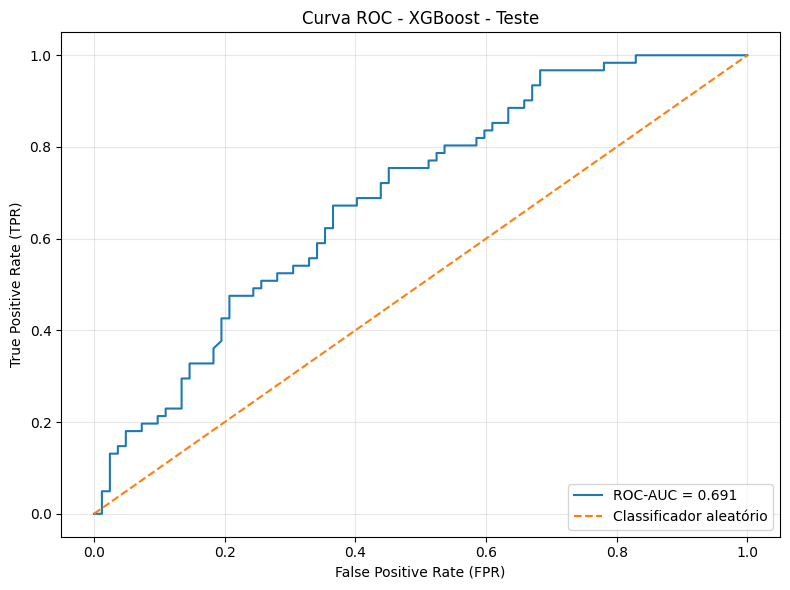

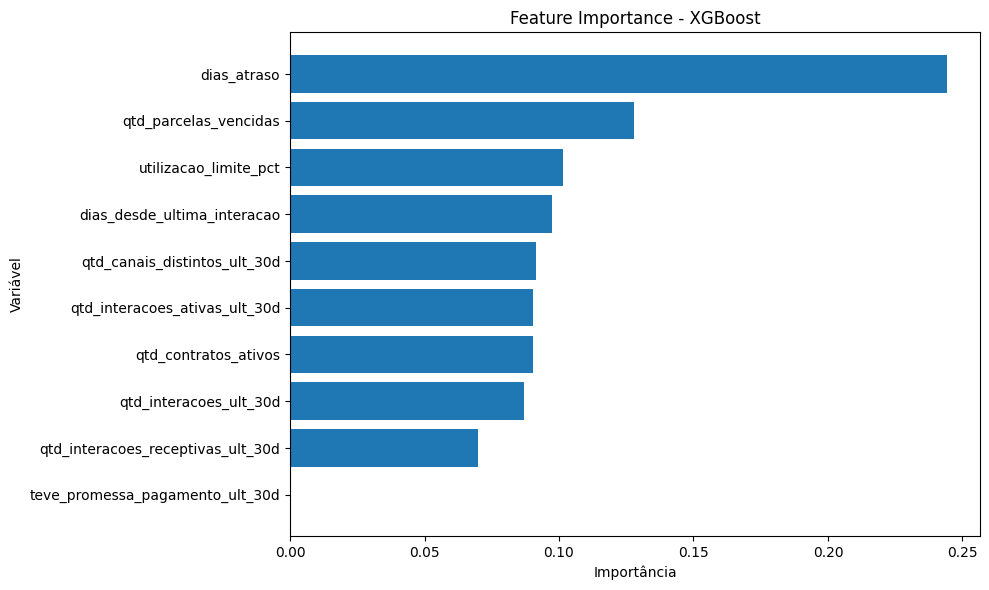


INFERÊNCIA FINAL - TESTE
   id_cliente data_referencia  dias_atraso  qtd_parcelas_vencidas  \
21     PJ0022      2026-06-30           48                      3   
31     PJ0032      2026-06-30           11                      1   
41     PJ0042      2026-06-30           11                      1   
44     PJ0045      2026-06-30           85                      4   
47     PJ0048      2026-06-30           29                      1   

    utilizacao_limite_pct  qtd_contratos_ativos  regularizou_30d  \
21                 0.2924                     2                1   
31                 0.6458                     1                1   
41                 0.2454                     2                1   
44                 0.5011                     2                1   
47                 0.4562                     3                0   

    qtd_interacoes_ult_30d  dias_desde_ultima_interacao  \
21                     1.0                          5.0   
31                     0.0      

In [122]:
# ============================================================
# SEED
# ============================================================

SEED = 42


# ============================================================
# 1. MODELOS DISPONÍVEIS
# ============================================================

modelos_disponiveis = {

    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=SEED
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    ),

    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        eval_metric='logloss',
        n_jobs=-1
    )
}


# ============================================================
# 2. SELECIONE OS MODELOS
# ============================================================

modelos_selecionados = [
    #'Decision Tree',
    #'Random Forest',
    'XGBoost'
]


# Verificar modelos
for nome in modelos_selecionados:

    if nome not in modelos_disponiveis:

        raise ValueError(
            f'Modelo "{nome}" não existe. '
            f'Escolha entre: '
            f'{list(modelos_disponiveis.keys())}'
        )


modelos = {
    nome: modelos_disponiveis[nome]
    for nome in modelos_selecionados
}


# ============================================================
# 3. PREPARAÇÃO DOS DADOS
# ============================================================

colunas_remover = [
    'regularizou_30d',
    'id_cliente',
    'data_referencia',
    'ano_mes'
]


X_treino = clientes_treino.drop(
    columns=colunas_remover,
    errors='ignore'
)

y_treino = clientes_treino[
    'regularizou_30d'
]


X_teste = clientes_teste.drop(
    columns=colunas_remover,
    errors='ignore'
)

y_teste = clientes_teste[
    'regularizou_30d'
]


# Garantir exatamente as mesmas features
X_teste = X_teste[
    X_treino.columns
]


# ============================================================
# 4. CROSS VALIDATION K = 5
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)


resultados_cv = []


for nome, modelo in modelos.items():

    print('\n' + '=' * 60)
    print(f'Treinando: {nome}')
    print('=' * 60)

    scores_f1 = cross_val_score(
        modelo,
        X_treino,
        y_treino,
        cv=cv,
        scoring='f1',
        n_jobs=-1
    )

    print(
        'F1 por fold:',
        np.round(scores_f1, 4)
    )

    print(
        f'F1 médio: {scores_f1.mean():.4f}'
    )

    print(
        f'Desvio padrão: {scores_f1.std():.4f}'
    )

    resultados_cv.append({
        'modelo': nome,
        'f1_medio': scores_f1.mean(),
        'f1_std': scores_f1.std()
    })


# ============================================================
# 5. RESULTADOS
# ============================================================

resultado_modelos = pd.DataFrame(
    resultados_cv
).sort_values(
    'f1_medio',
    ascending=False
).reset_index(drop=True)


print('\n' + '=' * 60)
print('RESULTADO CROSS VALIDATION')
print('=' * 60)

print(resultado_modelos)


# ============================================================
# 6. MELHOR MODELO
# ============================================================

melhor_nome = resultado_modelos.loc[
    0,
    'modelo'
]


melhor_modelo = modelos[
    melhor_nome
]


print(
    f'\n🏆 Melhor modelo pela F1: {melhor_nome}'
)


# ============================================================
# 7. TREINAR MELHOR MODELO
# ============================================================

melhor_modelo.fit(
    X_treino,
    y_treino
)


# ============================================================
# 8. AVALIAÇÃO
# ============================================================

metricas = avaliar_modelo(
    melhor_modelo,
    X_treino,
    y_treino,
    X_teste,
    y_teste
)


print('\n' + '=' * 60)
print('MÉTRICAS TREINO VS TESTE')
print('=' * 60)

print(metricas)


# ============================================================
# 9. CURVA ROC
# ============================================================

plotar_curva_roc(
    melhor_modelo,
    X_teste,
    y_teste,
    titulo=f'Curva ROC - {melhor_nome} - Teste'
)


# ============================================================
# 10. FEATURE IMPORTANCE
# ============================================================

plotar_feature_importance(
    melhor_modelo,
    X_treino,
    titulo=f'Feature Importance - {melhor_nome}',
    top_n=10
)


# ============================================================
# 11. INFERÊNCIA FINAL - TESTE
# ============================================================

# Probabilidade da classe 1
probabilidades = melhor_modelo.predict_proba(
    X_teste
)[:, 1]


# Previsão da classe
previsoes = melhor_modelo.predict(
    X_teste
)


# ------------------------------------------------------------
# Começar com TODOS os dados originais do teste
# ------------------------------------------------------------

resultado_inferencia = clientes_teste.copy()


# ------------------------------------------------------------
# Adicionar previsão do modelo
# ------------------------------------------------------------

resultado_inferencia['previsao'] = previsoes


# ------------------------------------------------------------
# Adicionar probabilidade de regularização
# ------------------------------------------------------------

resultado_inferencia[
    'prob_regularizacao'
] = probabilidades


# ------------------------------------------------------------
# Organizar colunas
# ------------------------------------------------------------

colunas_finais = [
    'id_cliente',
    'data_referencia'
]

# Colocar as demais features
colunas_finais += [
    coluna
    for coluna in clientes_teste.columns
    if coluna not in [
        'id_cliente',
        'data_referencia'
    ]
]

# Colocar previsão e probabilidade no final
colunas_finais += [
    'previsao',
    'prob_regularizacao'
]


resultado_inferencia = resultado_inferencia[
    colunas_finais
]


print('\n' + '=' * 60)
print('INFERÊNCIA FINAL - TESTE')
print('=' * 60)

print(
    resultado_inferencia.head()
)


print(
    f'\nQuantidade de registros: '
    f'{len(resultado_inferencia)}'
)


print(
    f'Quantidade de colunas: '
    f'{resultado_inferencia.shape[1]}'
)


# ============================================================
# 12. SALVAR MODELO
# ============================================================

nome_arquivo = (
    melhor_nome
    .lower()
    .replace(' ', '_')
    + '_regularizacao.pkl'
)


salvar_modelo(
    melhor_modelo,
    nome_arquivo
)


print(
    f'\nModelo salvo: {nome_arquivo}'
)


# ============================================================
# 13. SALVAR INFERÊNCIA FINAL
# ============================================================

nome_arquivo_resultado = (
    melhor_nome
    .lower()
    .replace(' ', '_')
    + '_inferencia_teste.csv'
)


salvar_resultado(
    resultado_inferencia,
    nome_arquivo_resultado,
    pasta='resultados'
)


print(
    f'\nInferência salva: '
    f'resultados/{nome_arquivo_resultado}'
)

In [123]:
resultado_inferencia

,id_cliente,data_referencia,dias_atraso,qtd_parcelas_vencidas,utilizacao_limite_pct,qtd_contratos_ativos,regularizou_30d,qtd_interacoes_ult_30d,dias_desde_ultima_interacao,qtd_canais_distintos_ult_30d,qtd_interacoes_ativas_ult_30d,qtd_interacoes_receptivas_ult_30d,teve_promessa_pagamento_ult_30d,qtd_promessas_pagamento_ult_30d,ano_mes,previsao,prob_regularizacao
21,PJ0022,2026-06-30,48,3,0.2924,2,1,1.0,5.0,1.0,1.0,0.0,0.0,0.0,2026-06,1,0.574306
31,PJ0032,2026-06-30,11,1,0.6458,1,1,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,2026-06,1,0.657522
41,PJ0042,2026-06-30,11,1,0.2454,2,1,1.0,18.0,1.0,1.0,0.0,0.0,0.0,2026-06,1,0.693283
44,PJ0045,2026-06-30,85,4,0.5011,2,1,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,2026-06,0,0.166887
47,PJ0048,2026-06-30,29,1,0.4562,3,0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,2026-06,1,0.675730
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,PJ0773,2026-06-30,79,3,0.6386,2,0,1.0,25.0,1.0,0.0,1.0,0.0,0.0,2026-06,1,0.535934
783,PJ0784,2026-06-30,99,5,0.3068,2,0,2.0,18.0,2.0,2.0,0.0,0.0,0.0,2026-06,0,0.123475
784,PJ0785,2026-06-30,44,2,0.2880,4,1,1.0,2.0,1.0,0.0,1.0,0.0,0.0,2026-06,1,0.677656
786,PJ0787,2026-06-30,33,3,0.6102,2,0,1.0,18.0,1.0,1.0,0.0,0.0,0.0,2026-06,1,0.576349


Embora o modelo RandomForest saiu melhor em relação aos demais (0.67 contra 0.65), o mesmo deu um poder de concentração altíssimo em relação a primeira FEATURE [dias_atraso]. O modelo XGBOOT distribui melhor o poder de inferência entre as features.

<h4> Efetuando Hiperturning do modelo </h4> 


PARÂMETROS ORIGINAIS DO MODELO
n_estimators: 100
max_depth: 3
learning_rate: 0.05
min_child_weight: None
subsample: 0.8
colsample_bytree: 0.8

PARÂMETROS QUE SERÃO TUNADOS
n_estimators: [50, 100, 150, 200, 300]
max_depth: [2, 3, 4, 5]
learning_rate: [0.01, 0.03, 0.05, 0.08, 0.1]
min_child_weight: [1, 3, 5, 10]
subsample: [0.7, 0.8, 0.9, 1.0]
colsample_bytree: [0.7, 0.8, 0.9, 1.0]

INICIANDO HYPERPARAMETER TUNING
Fitting 5 folds for each of 20 candidates, totalling 100 fits

RESULTADO DO TUNING
F1 médio CV: 0.6831

Melhores parâmetros encontrados:
n_estimators: 100
max_depth: 3
learning_rate: 0.03
min_child_weight: 10
subsample: 0.9
colsample_bytree: 0.7


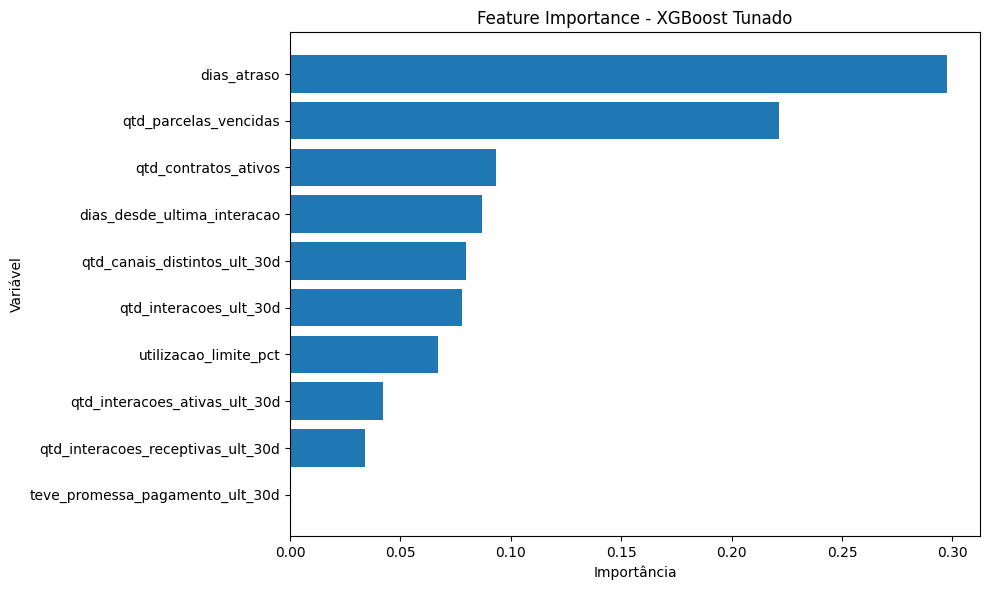


MÉTRICAS - XGBOOST TUNADO
             Treino     Teste
Accuracy   0.709285  0.622378
Precision  0.692913  0.543210
Recall     0.781065  0.721311
F1         0.734353  0.619718
ROC-AUC    0.775380  0.676329


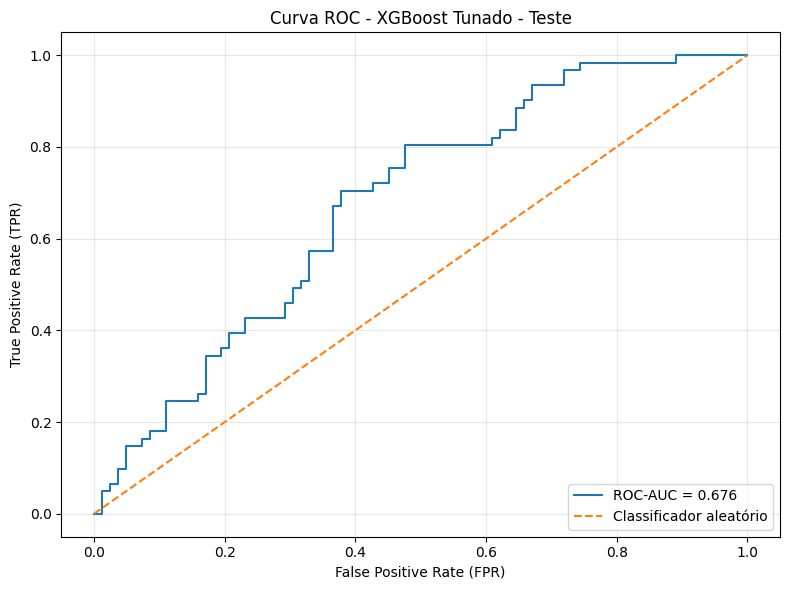


INFERÊNCIA FINAL - TESTE
   id_cliente data_referencia  dias_atraso  qtd_parcelas_vencidas  \
21     PJ0022      2026-06-30           48                      3   
31     PJ0032      2026-06-30           11                      1   
41     PJ0042      2026-06-30           11                      1   
44     PJ0045      2026-06-30           85                      4   
47     PJ0048      2026-06-30           29                      1   

    utilizacao_limite_pct  qtd_contratos_ativos  regularizou_30d  \
21                 0.2924                     2                1   
31                 0.6458                     1                1   
41                 0.2454                     2                1   
44                 0.5011                     2                1   
47                 0.4562                     3                0   

    qtd_interacoes_ult_30d  dias_desde_ultima_interacao  \
21                     1.0                          5.0   
31                     0.0      

In [133]:
# ============================================================
# 11. HYPERPARAMETER TUNING
# ============================================================

melhor_modelo_tunado, resultado_tuning = tunar_melhor_modelo(
    melhor_modelo,
    X_treino,
    y_treino,
    seed=SEED,
    cv=5,
    n_iter=20
)


# ============================================================
# 12. FEATURE IMPORTANCE
# ============================================================

plotar_feature_importance(
    melhor_modelo_tunado,
    X_treino,
    titulo='Feature Importance - XGBoost Tunado',
    top_n=10
)


# ============================================================
# 13. AVALIAÇÃO
# ============================================================

metricas_tunado = avaliar_modelo(
    melhor_modelo_tunado,
    X_treino,
    y_treino,
    X_teste,
    y_teste
)

print('\n' + '=' * 60)
print('MÉTRICAS - XGBOOST TUNADO')
print('=' * 60)

print(metricas_tunado)


# ============================================================
# 14. CURVA ROC
# ============================================================

plotar_curva_roc(
    melhor_modelo_tunado,
    X_teste,
    y_teste,
    titulo='Curva ROC - XGBoost Tunado - Teste'
)


# ============================================================
# 15. INFERÊNCIA FINAL - TESTE
# ============================================================

# ------------------------------------------------------------
# Probabilidade da classe 1
# ------------------------------------------------------------

probabilidades = melhor_modelo_tunado.predict_proba(
    X_teste
)[:, 1]


# ------------------------------------------------------------
# Previsão da classe
# ------------------------------------------------------------

previsoes = melhor_modelo_tunado.predict(
    X_teste
)


# ------------------------------------------------------------
# Começar com TODOS os dados originais do teste
# ------------------------------------------------------------

resultado_inferencia = clientes_teste.copy()


# ------------------------------------------------------------
# Adicionar previsão
# ------------------------------------------------------------

resultado_inferencia['previsao'] = previsoes


# ------------------------------------------------------------
# Adicionar probabilidade de regularização
# ------------------------------------------------------------

resultado_inferencia[
    'prob_regularizacao'
] = probabilidades


# ------------------------------------------------------------
# Organizar colunas
# ------------------------------------------------------------

colunas_finais = [
    'id_cliente',
    'data_referencia'
]


# Adicionar todas as demais colunas originais
colunas_finais += [
    coluna
    for coluna in clientes_teste.columns
    if coluna not in [
        'id_cliente',
        'data_referencia'
    ]
]


# Previsão e probabilidade ficam por último
colunas_finais += [
    'previsao',
    'prob_regularizacao'
]


resultado_inferencia = resultado_inferencia[
    colunas_finais
]


# ============================================================
# 16. EXIBIR INFERÊNCIA
# ============================================================

print('\n' + '=' * 60)
print('INFERÊNCIA FINAL - TESTE')
print('=' * 60)

print(
    resultado_inferencia.head()
)

print(
    f'\nQuantidade de registros: '
    f'{len(resultado_inferencia)}'
)

print(
    f'Quantidade de colunas: '
    f'{resultado_inferencia.shape[1]}'
)


# ============================================================
# 17. SALVAR MODELO TUNADO
# ============================================================

nome_arquivo_modelo = (
    'xgboost_tunado_regularizacao.pkl'
)


salvar_modelo(
    melhor_modelo_tunado,
    nome_arquivo_modelo
)


print(
    f'\nModelo salvo: '
    f'{nome_arquivo_modelo}'
)


# ============================================================
# 18. SALVAR INFERÊNCIA FINAL
# ============================================================

nome_arquivo_resultado = (
    'xgboost_tunado_inferencia_teste.csv'
)


salvar_resultado(
    resultado_inferencia,
    nome_arquivo_resultado,
    pasta='../resultados'
)


print(
    f'\nInferência salva: '
    f'../resultados/{nome_arquivo_resultado}'
)

<h4> Efetuando inferências avulso. </h4>

A base toda será usada e não somente a que foi treinada o modelo.

In [62]:
# 1 - Carregando o modelo
modelo_final = carregar_modelo("xgboost_tunado_regularizacao.pkl", pasta='../modelos')
print(f"Modelo carregado {type(modelo_final)}")

Modelo carregado de: ../modelos\xgboost_tunado_regularizacao.pkl
Modelo carregado <class 'xgboost.sklearn.XGBClassifier'>


In [77]:
#============================================================
# PREPARAÇÃO DOS DADOS
# ============================================================

colunas_remover = [
    'regularizou_30d',
    'id_cliente',
    'data_referencia',
    'ano_mes'
]

X_treino = clientes_treino.drop(
    columns=colunas_remover,
    errors='ignore'
)

y_treino = clientes_treino[
    'regularizou_30d'
]


X_teste = clientes_teste.drop(
    columns=colunas_remover,
    errors='ignore'
)

y_teste = clientes_teste[
    'regularizou_30d'
]


# Garantir exatamente as mesmas features
X_teste = X_teste[
    X_treino.columns
]

In [68]:
y_teste

21     1
31     1
41     1
44     1
47     0
      ..
772    0
783    0
784    1
786    0
793    1
Name: regularizou_30d, Length: 143, dtype: int64

In [78]:
# Juntar treino + teste
X_todos = pd.concat(
    [
        X_treino,
        X_teste
    ],
    axis=0
)

In [72]:
X_todos

,dias_atraso,qtd_parcelas_vencidas,utilizacao_limite_pct,qtd_contratos_ativos,qtd_interacoes_ult_30d,dias_desde_ultima_interacao,qtd_interacoes_ativas_ult_30d,qtd_interacoes_receptivas_ult_30d,qtd_canais_distintos_ult_30d,teve_promessa_pagamento_ult_30d,qtd_promessas_pagamento_ult_30d
0,53,2,0.3139,4,2.0,1.0,2.0,0.0,2.0,1.0,1.0
1,24,1,0.5994,1,0.0,-1.0,0.0,0.0,0.0,0.0,0.0
2,52,3,0.6230,4,1.0,27.0,1.0,0.0,1.0,1.0,1.0
3,45,1,0.3296,1,1.0,19.0,0.0,1.0,1.0,0.0,0.0
4,43,1,0.1913,2,2.0,2.0,2.0,0.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
772,79,3,0.6386,2,1.0,25.0,0.0,1.0,1.0,0.0,0.0
783,99,5,0.3068,2,2.0,18.0,2.0,0.0,2.0,0.0,0.0
784,44,2,0.2880,4,1.0,2.0,0.0,1.0,1.0,0.0,0.0
786,33,3,0.6102,2,1.0,18.0,1.0,0.0,1.0,0.0,0.0


In [80]:
# ============================================================
# INFERÊNCIA FINAL — TODOS OS CLIENTES
# ============================================================

# ------------------------------------------------------------
# Features exatamente na ordem utilizada no treinamento
# ------------------------------------------------------------

colunas_features = [
    'dias_atraso',
    'qtd_parcelas_vencidas',
    'utilizacao_limite_pct',
    'qtd_contratos_ativos',
    'qtd_interacoes_ult_30d',
    'dias_desde_ultima_interacao',
    'qtd_canais_distintos_ult_30d',
    'qtd_interacoes_ativas_ult_30d',
    'qtd_interacoes_receptivas_ult_30d',
    'teve_promessa_pagamento_ult_30d',
    'qtd_promessas_pagamento_ult_30d'
]


# ------------------------------------------------------------
# Montar X com exatamente as features do modelo
# ------------------------------------------------------------

X_todos = clientes_features_target[
    colunas_features
].copy()


# ------------------------------------------------------------
# Probabilidade da classe 1
# ------------------------------------------------------------

probabilidades = modelo_final.predict_proba(
    X_todos
)[:, 1]


# ------------------------------------------------------------
# Previsão da classe
# ------------------------------------------------------------

previsoes = modelo_final.predict(
    X_todos
)


# ============================================================
# RESULTADO DA INFERÊNCIA
# ============================================================

resultado_inferencia = (
    clientes_features_target[
        [
            'id_cliente',
            'data_referencia'
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# Adicionar previsão
# ------------------------------------------------------------

resultado_inferencia[
    'previsao'
] = previsoes


# ------------------------------------------------------------
# Adicionar probabilidade
# ------------------------------------------------------------

resultado_inferencia[
    'prob_regularizacao'
] = probabilidades

In [81]:
resultado_inferencia

,id_cliente,data_referencia,previsao,prob_regularizacao
0,PJ0001,2026-02-28,1,0.503472
1,PJ0002,2026-02-28,1,0.676824
2,PJ0003,2026-01-28,0,0.498950
3,PJ0004,2026-01-28,1,0.569566
4,PJ0005,2026-02-28,1,0.605529
...,...,...,...,...
795,PJ0796,2026-05-28,0,0.471269
796,PJ0797,2026-04-30,1,0.722564
797,PJ0798,2026-03-28,0,0.213719
798,PJ0799,2026-05-28,0,0.190608


In [84]:
# ============================================================
# HORIZONTE DA PREVISÃO
# ============================================================
# Acrescemtamdp
resultado_inferencia['data_referencia'] = pd.to_datetime(
    resultado_inferencia['data_referencia']
)

resultado_inferencia['data_inicio_horizonte'] = (
    resultado_inferencia['data_referencia']
    + pd.Timedelta(days=1)
)

resultado_inferencia['data_fim_horizonte'] = (
    resultado_inferencia['data_referencia']
    + pd.Timedelta(days=30)
)

In [ ]:
resultado_inferencia.columns

,id_cliente,data_referencia,previsao,prob_regularizacao,data_inicio_horizonte,data_fim_horizonte
0,PJ0001,2026-02-28,1,0.503472,2026-03-01,2026-03-30
1,PJ0002,2026-02-28,1,0.676824,2026-03-01,2026-03-30
2,PJ0003,2026-01-28,0,0.498950,2026-01-29,2026-02-27
3,PJ0004,2026-01-28,1,0.569566,2026-01-29,2026-02-27
4,PJ0005,2026-02-28,1,0.605529,2026-03-01,2026-03-30
...,...,...,...,...,...,...
795,PJ0796,2026-05-28,0,0.471269,2026-05-29,2026-06-27
796,PJ0797,2026-04-30,1,0.722564,2026-05-01,2026-05-30
797,PJ0798,2026-03-28,0,0.213719,2026-03-29,2026-04-27
798,PJ0799,2026-05-28,0,0.190608,2026-05-29,2026-06-27


In [86]:
# ============================================================
# SALVAR INFERÊNCIA FINAL
# ============================================================

resultado_inferencia.to_csv(
    "../resultados/xgboost_inferencia_todos.csv",
    index=False
)